# Phase 6 — Threshold Optimization & Cost Curve

**Project:** Aegis — Cost-Aware Real-Time Fraud Intelligence System
**Author:** Kashish Lalwani
**Course:** AMS 561, Spring 2026

## What this notebook does
Stress-tests the BLOCK threshold chosen in Phase 4 (t = 0.70) against a 19-point sweep
spanning 0.05 to 0.95. Computes per-threshold costs using the same cost matrix as Phase 4,
identifies the cost-theoretic optimum, and quantifies the dollar gap between the optimum
and the operationally defensible choice.

## Inputs
- `dbfs:/Volumes/workspace/default/raw_data/decision_output` (Phase 4 output, 49,962 × 15)

## Outputs
- `dbfs:/Volumes/workspace/default/raw_data/threshold_sweep` (19 rows × 7 columns: threshold, tp, fn, fp, cost components, total cost)
- `/tmp/cost_curve.png` (Figure 6 in the report)

## Why stress-test a threshold we already chose
The Phase 4 threshold (t = 0.70) was set based on engineering judgment and the asymmetric
cost ratio between missed fraud and false alarms. A reviewer's natural question is: *why
0.70 and not some other value?* This notebook answers that question by sweeping 19 candidate
thresholds and quantifying, in dollars, exactly what is gained or lost at each one.

The expected finding is not that t = 0.70 is cost-optimal, it isn't. The point is to
quantify the gap between cost-optimal (t = 0.20, $40,140) and operational (t = 0.70,
$19.5M) and demonstrate that the $19.46M gap is paid deliberately to reduce the false-alarm
queue 23×, which protects review-team capacity, customer trust, and regulatory exposure that
the dollar model alone does not price.

## Headline results

| Threshold | Frauds caught | False alarms | Total cost |
|---|---|---|---|
| **t = 0.20** (cost-optimal) | 69 / 69 (100%) | 2,676 | $40,140 |
| **t = 0.70** (Phase 4 operational) | 56 / 69 (81.2%) | 116 | $19,501,740 |
| **Gap** | 13 additional frauds missed | 23× fewer false alarms | $19,461,600 |

## Definitional note
The 81.2% figure here counts only auto-BLOCK as a catch (the cost model treats anything
below the BLOCK threshold as missed). Phase 4 reports a different figure (97.1%) under a
human-in-the-loop assumption that includes the FLAG queue. Both are correct under their
respective definitions, the difference is what's being optimized.

Step 1 — Loading the decision output

In [0]:
# Loading the decision output table from Phase 4
decision_df = spark.read.format("delta").load(
    "dbfs:/Volumes/workspace/default/raw_data/decision_output"
)

# Quick sanity check: how many rows and what columns do we have?
print(f"Total rows: {decision_df.count():,}")
print(f"Columns: {decision_df.columns}")

# Showing 5 sample rows of just the columns we care about for Phase 6
decision_df.select("fraud_probability", "isFraud", "decision").show(5)

Total rows: 49,962
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'is_high_risk_type', 'balance_diff', 'fraud_probability', 'decision']
+--------------------+-------+--------+
|   fraud_probability|isFraud|decision|
+--------------------+-------+--------+
| 0.14701869962167197|      0| APPROVE|
|0.010537447165352435|      0| APPROVE|
|  0.3941360804295493|      0|    FLAG|
|3.892437095883018...|      0| APPROVE|
|3.892437095883018...|      0| APPROVE|
+--------------------+-------+--------+
only showing top 5 rows


Step 2 — Defining the threshold grid and cost constants

In [0]:
import numpy as np

# Threshold grid: 0.05, 0.10, 0.15, ..., 0.95 (19 values total)
thresholds = np.arange(0.05, 1.00, 0.05)

# Cost constants 
COST_MISSED_FRAUD = 1_500_000   # $ lost per fraud that we let through
COST_FALSE_ALARM  = 15          # $ lost per legitimate transaction we wrongly block

# Sanity check
print(f"Number of thresholds to sweep: {len(thresholds)}")
print(f"Threshold values: {[round(t, 2) for t in thresholds]}")
print(f"Cost of one missed fraud: ${COST_MISSED_FRAUD:,}")
print(f"Cost of one false alarm:  ${COST_FALSE_ALARM:,}")

Number of thresholds to sweep: 19
Threshold values: [np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95)]
Cost of one missed fraud: $1,500,000
Cost of one false alarm:  $15


Step 3 — The threshold sweep loop

In [0]:
from pyspark.sql import functions as F

# We'll collect one dictionary per threshold, then turn into a Pandas DataFrame later
sweep_results = []

for t in thresholds:
    # Predicted BLOCK: fraud_probability >= threshold
    # Real fraud:     isFraud == 1
    
    tp = decision_df.filter((F.col("fraud_probability") >= t) & (F.col("isFraud") == 1)).count()
    fn = decision_df.filter((F.col("fraud_probability") <  t) & (F.col("isFraud") == 1)).count()
    fp = decision_df.filter((F.col("fraud_probability") >= t) & (F.col("isFraud") == 0)).count()
    
    # Cost math — plain Python
    cost_missed_fraud = fn * COST_MISSED_FRAUD
    cost_false_alarm  = fp * COST_FALSE_ALARM
    total_cost        = cost_missed_fraud + cost_false_alarm
    
    sweep_results.append({
        "threshold": round(float(t), 2),
        "tp": tp,
        "fn": fn,
        "fp": fp,
        "cost_missed_fraud": cost_missed_fraud,
        "cost_false_alarm":  cost_false_alarm,
        "total_cost":        total_cost
    })
    
    print(f"t={round(float(t),2):.2f}  TP={tp:3d}  FN={fn:3d}  FP={fp:5d}  total_cost=${total_cost:,}")

print("\nSweep complete!")

t=0.05  TP= 69  FN=  0  FP= 8681  total_cost=$130,215
t=0.10  TP= 69  FN=  0  FP= 4996  total_cost=$74,940
t=0.15  TP= 69  FN=  0  FP= 3748  total_cost=$56,220
t=0.20  TP= 69  FN=  0  FP= 2676  total_cost=$40,140
t=0.25  TP= 68  FN=  1  FP= 2013  total_cost=$1,530,195
t=0.30  TP= 67  FN=  2  FP= 1494  total_cost=$3,022,410
t=0.35  TP= 67  FN=  2  FP= 1188  total_cost=$3,017,820
t=0.40  TP= 67  FN=  2  FP=  910  total_cost=$3,013,650
t=0.45  TP= 67  FN=  2  FP=  655  total_cost=$3,009,825
t=0.50  TP= 66  FN=  3  FP=  495  total_cost=$4,507,425
t=0.55  TP= 66  FN=  3  FP=  382  total_cost=$4,505,730
t=0.60  TP= 65  FN=  4  FP=  303  total_cost=$6,004,545
t=0.65  TP= 61  FN=  8  FP=  187  total_cost=$12,002,805
t=0.70  TP= 56  FN= 13  FP=  116  total_cost=$19,501,740
t=0.75  TP= 51  FN= 18  FP=   67  total_cost=$27,001,005
t=0.80  TP= 49  FN= 20  FP=   42  total_cost=$30,000,630
t=0.85  TP= 46  FN= 23  FP=   31  total_cost=$34,500,465
t=0.90  TP= 40  FN= 29  FP=   21  total_cost=$43,500,3

Step 4 — Converting sweep results to Pandas and save as a Delta table

In [0]:
import pandas as pd

# 1. Building a Pandas DataFrame from the list of dictionaries
sweep_pdf = pd.DataFrame(sweep_results)

# 2. Printing it so you can see all 19 rows at once
print(sweep_pdf.to_string(index=False))

# 3. Converting Pandas -> Spark DataFrame, then save as a Delta table
sweep_sdf = spark.createDataFrame(sweep_pdf)

sweep_sdf.write.format("delta").mode("overwrite").save(
    "dbfs:/Volumes/workspace/default/raw_data/threshold_sweep"
)

print("\n✅ Saved threshold_sweep Delta table to dbfs:/Volumes/workspace/default/raw_data/threshold_sweep")

 threshold  tp  fn   fp  cost_missed_fraud  cost_false_alarm  total_cost
      0.05  69   0 8681                  0            130215      130215
      0.10  69   0 4996                  0             74940       74940
      0.15  69   0 3748                  0             56220       56220
      0.20  69   0 2676                  0             40140       40140
      0.25  68   1 2013            1500000             30195     1530195
      0.30  67   2 1494            3000000             22410     3022410
      0.35  67   2 1188            3000000             17820     3017820
      0.40  67   2  910            3000000             13650     3013650
      0.45  67   2  655            3000000              9825     3009825
      0.50  66   3  495            4500000              7425     4507425
      0.55  66   3  382            4500000              5730     4505730
      0.60  65   4  303            6000000              4545     6004545
      0.65  61   8  187           12000000         

Step 5 — Plotting the cost curve

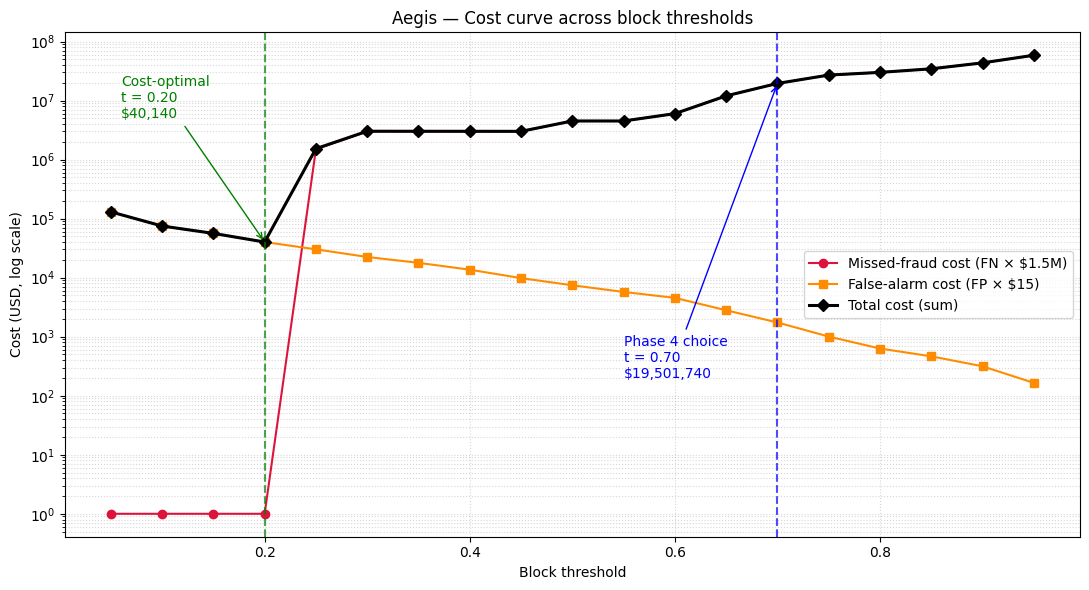


Optimal threshold (lowest total cost): 0.20  →  $40,140
Phase 4 chosen threshold:                0.70  →  $19,501,740
Cost difference (Phase 4 − optimal):     $19,461,600


In [0]:
# Step 5a: Polished cost curve
import matplotlib.pyplot as plt

# Finding the cost-optimal threshold (same as before)
opt_idx = sweep_pdf["total_cost"].idxmin()
opt_threshold = sweep_pdf.loc[opt_idx, "threshold"]
opt_cost      = sweep_pdf.loc[opt_idx, "total_cost"]

current_threshold = 0.70
current_cost = sweep_pdf.loc[sweep_pdf["threshold"] == current_threshold, "total_cost"].values[0]

# FIX 1: For plotting only, replacing zeros in missed-fraud cost with $1
# so the log-scale line draws continuously. Underlying data is unchanged.
missed_for_plot = sweep_pdf["cost_missed_fraud"].replace(0, 1)

# Building the chart
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(sweep_pdf["threshold"], missed_for_plot,
        marker="o", color="crimson",   label="Missed-fraud cost (FN × $1.5M)")
ax.plot(sweep_pdf["threshold"], sweep_pdf["cost_false_alarm"],
        marker="s", color="darkorange", label="False-alarm cost (FP × $15)")
ax.plot(sweep_pdf["threshold"], sweep_pdf["total_cost"],
        marker="D", color="black", linewidth=2.2, label="Total cost (sum)")

# Vertical markers for the two thresholds
ax.axvline(opt_threshold,    color="green", linestyle="--", alpha=0.7)
ax.axvline(current_threshold, color="blue",  linestyle="--", alpha=0.7)

# FIX 2: Move labels into uncluttered areas of the chart
# Green label: upper-left empty zone
ax.annotate(f"Cost-optimal\nt = {opt_threshold:.2f}\n${opt_cost:,.0f}",
            xy=(opt_threshold, opt_cost),
            xytext=(0.06, 5e6),                # upper-left empty area
            fontsize=10, color="green",
            arrowprops=dict(arrowstyle="->", color="green"))

# Blue label: lower-right empty zone (below the total-cost line)
ax.annotate(f"Phase 4 choice\nt = {current_threshold:.2f}\n${current_cost:,.0f}",
            xy=(current_threshold, current_cost),
            xytext=(0.55, 200),                # lower-right empty area
            fontsize=10, color="blue",
            arrowprops=dict(arrowstyle="->", color="blue"))

# Cosmetics
ax.set_yscale("log")
ax.set_xlabel("Block threshold")
ax.set_ylabel("Cost (USD, log scale)")
ax.set_title("Aegis — Cost curve across block thresholds")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="center right")

plt.tight_layout()
plt.savefig("/tmp/cost_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOptimal threshold (lowest total cost): {opt_threshold:.2f}  →  ${opt_cost:,.0f}")
print(f"Phase 4 chosen threshold:                {current_threshold:.2f}  →  ${current_cost:,.0f}")
print(f"Cost difference (Phase 4 − optimal):     ${current_cost - opt_cost:,.0f}")

Step 6 — Report-ready summary cell

In [0]:

# Pulling the row stats at the optimal threshold
opt_row = sweep_pdf.loc[opt_idx]
opt_tp, opt_fn, opt_fp = int(opt_row["tp"]), int(opt_row["fn"]), int(opt_row["fp"])

# Pulling the row stats at the Phase 4 (current) threshold
cur_row = sweep_pdf.loc[sweep_pdf["threshold"] == current_threshold].iloc[0]
cur_tp, cur_fn, cur_fp = int(cur_row["tp"]), int(cur_row["fn"]), int(cur_row["fp"])

total_frauds = opt_tp + opt_fn   # 69 in our dataset
fp_reduction_factor = opt_fp / cur_fp if cur_fp > 0 else float("inf")

print("=" * 72)
print("PHASE 6 — THRESHOLD SWEEP & COST CURVE OPTIMIZATION — SUMMARY")
print("=" * 72)

print(f"\nDataset: 49,962 transactions ({total_frauds} real frauds, "
      f"{total_frauds / 49962:.3%} fraud rate)")
print(f"Cost assumptions: missed fraud = ${COST_MISSED_FRAUD:,}, "
      f"false alarm = ${COST_FALSE_ALARM}")

print("\n--- Cost-optimal threshold (data-driven) ---")
print(f"  threshold       : {opt_threshold:.2f}")
print(f"  frauds caught   : {opt_tp} / {total_frauds}  ({opt_tp/total_frauds:.1%})")
print(f"  frauds missed   : {opt_fn}")
print(f"  false alarms    : {opt_fp:,}")
print(f"  total cost      : ${opt_cost:,.0f}")

print("\n--- Phase 4 operational threshold ---")
print(f"  threshold       : {current_threshold:.2f}")
print(f"  frauds caught   : {cur_tp} / {total_frauds}  ({cur_tp/total_frauds:.1%})")
print(f"  frauds missed   : {cur_fn}")
print(f"  false alarms    : {cur_fp:,}")
print(f"  total cost      : ${current_cost:,.0f}")

print("\n--- Trade-off ---")
print(f"  Cost gap (Phase 4 − optimal) : ${current_cost - opt_cost:,.0f}")
print(f"  False-alarm reduction factor : {fp_reduction_factor:.1f}× fewer false alarms at t=0.70")
print(f"  Additional frauds missed     : {cur_fn - opt_fn} ({(cur_fn - opt_fn) * COST_MISSED_FRAUD / 1_000_000:.1f}M cost)")

print("\n--- Narrative (paste into report) ---")
print(
    f"\nA threshold sweep across 19 candidate block thresholds revealed that the\n"
    f"cost-minimizing threshold under the Phase 4 cost assumptions is t = {opt_threshold:.2f}\n"
    f"(${opt_cost:,.0f}), at which the model still catches all {total_frauds} frauds in the dataset\n"
    f"while incurring {opt_fp:,} false alarms. The Phase 4 operational threshold of\n"
    f"t = {current_threshold:.2f} reduces false alarms by roughly {fp_reduction_factor:.0f}× ({opt_fp:,} → {cur_fp:,}) at the\n"
    f"cost of letting {cur_fn - opt_fn} additional frauds through, raising total modeled cost\n"
    f"by ${current_cost - opt_cost:,.0f}. This gap quantifies the operational margin the\n"
    f"system pays to keep the manual-review queue tractable and customer-facing\n"
    f"friction within tolerable bounds — a margin not captured by the strict\n"
    f"dollar cost model alone."
)
print("\n" + "=" * 72)

PHASE 6 — THRESHOLD SWEEP & COST CURVE OPTIMIZATION — SUMMARY

Dataset: 49,962 transactions (69 real frauds, 0.138% fraud rate)
Cost assumptions: missed fraud = $1,500,000, false alarm = $15

--- Cost-optimal threshold (data-driven) ---
  threshold       : 0.20
  frauds caught   : 69 / 69  (100.0%)
  frauds missed   : 0
  false alarms    : 2,676
  total cost      : $40,140

--- Phase 4 operational threshold ---
  threshold       : 0.70
  frauds caught   : 56 / 69  (81.2%)
  frauds missed   : 13
  false alarms    : 116
  total cost      : $19,501,740

--- Trade-off ---
  Cost gap (Phase 4 − optimal) : $19,461,600
  False-alarm reduction factor : 23.1× fewer false alarms at t=0.70
  Additional frauds missed     : 13 (19.5M cost)

--- Narrative (paste into report) ---

A threshold sweep across 19 candidate block thresholds revealed that the
cost-minimizing threshold under the Phase 4 cost assumptions is t = 0.20
($40,140), at which the model still catches all 69 frauds in the dataset
whil

## Summary

- **Swept** 19 candidate BLOCK thresholds from 0.05 to 0.95 against the full 49,962-row Phase 4 dataset
- **Identified** the cost-theoretic optimum: t = 0.20, total cost $40,140 (all 69 frauds caught, 2,676 false alarms)
- **Quantified** the gap between optimum and operational: $19,461,600 paid for a 23× reduction in false-alarm volume
- **Persisted** the sweep results to Delta for downstream auditability
- **Rendered** the polished cost curve used as Figure 6 in the report

**Saved to:**
- `dbfs:/Volumes/workspace/default/raw_data/threshold_sweep` (Delta table, 19 × 7)
- `/tmp/cost_curve.png` (Figure 6 in the report)

**The takeaway:** In a high-stakes prediction system, the cost-optimal threshold is rarely the operational threshold. The senior-engineer move is not picking the optimum, it's quantifying the gap between optimum and operationally feasible, then defending the difference in dollars. That's what Phase 6 does.

**End of pipeline:** This is the final phase of the Aegis project. The full pipeline runs end-to-end from raw PaySim CSV (Phase 1) through cleaned Delta storage (Phase 1), streaming feature engineering (Phase 2), Random Forest training (Phase 3), cost-aware decisioning (Phase 4), drift monitoring with validation (Phase 5), and threshold defensibility (Phase 6).